In [1]:
import pandas as pd

df = pd.read_csv('complaints_processed.csv')

df = df[['product', 'narrative']].copy()

df.dropna(subset=['narrative'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst row narrative:")
print(df['narrative'][0][:300])

C:\Users\vkank\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Shape: (162411, 2)

Columns: ['product', 'narrative']

First row narrative:
purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing r


In [2]:
print(df['product'].value_counts())
print(df.isnull().sum())

print(len(df))

product
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64
product      0
narrative    0
dtype: int64
162411


In [3]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)     
    text = re.sub(r'[^a-z\s]', '', text)           
    text = re.sub(r'\s+', ' ', text)               
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['cleaned_text'] = df['narrative'].apply(clean_text)

print("Sample raw text:")
print(df['narrative'][0][:200])
print("\nSample cleaned text:")
print(df['cleaned_text'][0][:200])
print("\nEmpty texts:", (df['cleaned_text'] == '').sum())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vkank\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sample raw text:
purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order 

Sample cleaned text:
purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded sorry inform due unusually high order volume order shi

Empty texts: 0


In [4]:
CRITICAL_WORDS = [
    'fraud', 'scam', 'stolen', 'unauthorized', 
    'identity theft', 'illegal', 'forgery', 'fake'
]

HIGH_WORDS = [
    'urgent', 'immediately', 'cannot access', 'not working',
    'error', 'failed', 'charged twice', 'refund', 
    'overcharged', 'denied', 'blocked', 'suspended'
]

MEDIUM_WORDS = [
    'issue', 'problem', 'complaint', 'delay', 
    'incorrect', 'wrong', 'missing', 'late', 'dispute'
]

def assign_priority(text):
    text = str(text).lower()
    if any(w in text for w in CRITICAL_WORDS):
        return 'Critical'
    elif any(w in text for w in HIGH_WORDS):
        return 'High'
    elif any(w in text for w in MEDIUM_WORDS):
        return 'Medium'
    else:
        return 'Low'

df['priority'] = df['narrative'].apply(assign_priority)

print(df['priority'].value_counts())
print("\nPriority %:")
print(df['priority'].value_counts(normalize=True).round(3) * 100)

priority
Critical    48547
Medium      47088
Low         37697
High        29079
Name: count, dtype: int64

Priority %:
priority
Critical    29.9
Medium      29.0
Low         23.2
High        17.9
Name: proportion, dtype: float64


In [5]:
if len(df) > 50000:
    df = df.sample(n=50000, random_state=42).reset_index(drop=True)
    print("Sampled to 50,000 rows")
else:
    print("Using full dataset:", len(df), "rows")

print("Category distribution after sampling:")
print(df['product'].value_counts())

Sampled to 50,000 rows
Category distribution after sampling:
product
credit_reporting       28010
debt_collection         7208
mortgages_and_loans     5782
credit_card             4818
retail_banking          4182
Name: count, dtype: int64


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,       
    ngram_range=(1, 2),       
    min_df=3,                 
    max_df=0.95,              
    sublinear_tf=True         
)

X = tfidf.fit_transform(df['cleaned_text'])

print("TF-IDF Matrix Shape:", X.shape)
print("Sample features:", tfidf.get_feature_names_out()[:20])

TF-IDF Matrix Shape: (50000, 10000)
Sample features: ['abide' 'ability' 'ability consumer' 'ability obtain' 'able'
 'able access' 'able disregard' 'able find' 'able get' 'able help'
 'able make' 'able obtain' 'able pay' 'able provide' 'able reach'
 'able request' 'able see' 'able speak' 'able use' 'able verify']


In [7]:
y_category = df['product']
y_priority  = df['priority']

print("Category Classes:", y_category.unique())
print("Priority Classes:", y_priority.unique())
print("\nCategory counts:")
print(y_category.value_counts())
print("\nPriority counts:")
print(y_priority.value_counts())

Category Classes: <ArrowStringArray>
['mortgages_and_loans',    'credit_reporting',     'debt_collection',
         'credit_card',      'retail_banking']
Length: 5, dtype: str
Priority Classes: <ArrowStringArray>
['Critical', 'High', 'Low', 'Medium']
Length: 4, dtype: str

Category counts:
product
credit_reporting       28010
debt_collection         7208
mortgages_and_loans     5782
credit_card             4818
retail_banking          4182
Name: count, dtype: int64

Priority counts:
priority
Critical    15133
Medium      14408
Low         11491
High         8968
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, accuracy_score

X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

models_cat = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Naive Bayes'         : MultinomialNB(alpha=0.1)
}

print("=== CATEGORY MODEL COMPARISON ===\n")
best_cat_model = None
best_cat_score = 0
best_cat_name  = ""

results_cat = {}

for name, model in models_cat.items():
    model.fit(X_train, y_train_cat)
    y_pred = model.predict(X_test)
    f1  = f1_score(y_test_cat, y_pred, average='weighted')
    acc = accuracy_score(y_test_cat, y_pred)
    results_cat[name] = {'accuracy': acc, 'f1': f1}
    print(name)
    print("Accuracy =", round(acc, 4))
    print("F1 Score =", round(f1, 4))
    print()

    if f1 > best_cat_score:
        best_cat_score = f1
        best_cat_model = model
        best_cat_name  = name

print("Best Model =", best_cat_model)
print("Best F1 Score =", round(best_cat_score, 4))

=== CATEGORY MODEL COMPARISON ===

Logistic Regression
Accuracy = 0.8668
F1 Score = 0.8656

Random Forest
Accuracy = 0.8514
F1 Score = 0.8457

Naive Bayes
Accuracy = 0.8265
F1 Score = 0.8286

Best Model = LogisticRegression(C=5, max_iter=1000, random_state=42)
Best F1 Score = 0.8656


In [9]:
X_train_p, X_test_p, y_train_pri, y_test_pri = train_test_split(
    X, y_priority,
    test_size=0.2,
    random_state=42,
    stratify=y_priority
)

models_pri = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Naive Bayes'         : MultinomialNB(alpha=0.1)
}

print("=== PRIORITY MODEL COMPARISON ===\n")
best_pri_model = None
best_pri_score = 0
best_pri_name  = ""

results_pri = {}

for name, model in models_pri.items():
    model.fit(X_train_p, y_train_pri)
    y_pred = model.predict(X_test_p)
    f1  = f1_score(y_test_pri, y_pred, average='weighted')
    acc = accuracy_score(y_test_pri, y_pred)
    results_pri[name] = {'accuracy': acc, 'f1': f1}
    print(name)
    print("Accuracy :", round(acc, 4))
    print("F1 Score :", round(f1, 4))
    print()



    if f1 > best_pri_score:
        best_pri_score = f1
        best_pri_model = model
        best_pri_name  = name

print("Best Priority Model =", best_pri_name)
print("F1 Score =", round(best_pri_score, 4))

=== PRIORITY MODEL COMPARISON ===

Logistic Regression
Accuracy : 0.9582
F1 Score : 0.9583

Random Forest
Accuracy : 0.9444
F1 Score : 0.9445

Naive Bayes
Accuracy : 0.7477
F1 Score : 0.7476

Best Priority Model = Logistic Regression
F1 Score = 0.9583


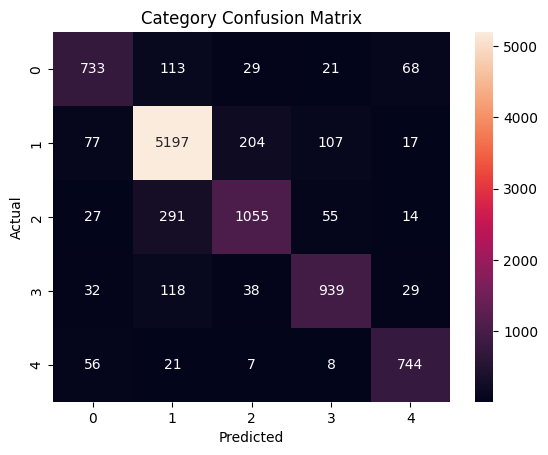

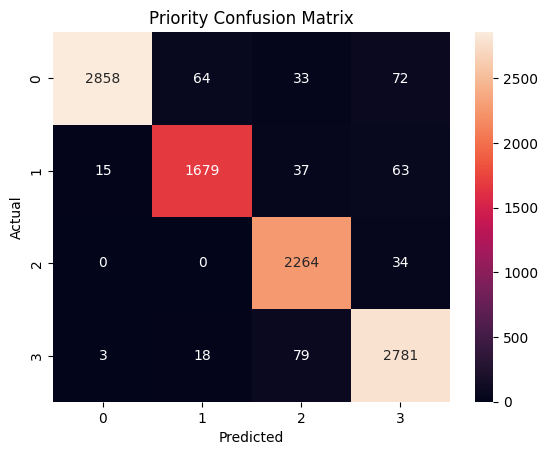

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_cat = best_cat_model.predict(X_test)

cm = confusion_matrix(y_test_cat, y_pred_cat)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Category Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



y_pred_pri = best_pri_model.predict(X_test_p)

cm = confusion_matrix(y_test_pri, y_pred_pri)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Priority Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
from sklearn.metrics import classification_report

print("=== CATEGORY CLASSIFICATION REPORT ===")
print(classification_report(y_test_cat, y_pred_cat))

print("=== PRIORITY CLASSIFICATION REPORT ===")
print(classification_report(y_test_pri, y_pred_pri))

=== CATEGORY CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

        credit_card       0.79      0.76      0.78       964
   credit_reporting       0.91      0.93      0.92      5602
    debt_collection       0.79      0.73      0.76      1442
mortgages_and_loans       0.83      0.81      0.82      1156
     retail_banking       0.85      0.89      0.87       836

           accuracy                           0.87     10000
          macro avg       0.83      0.82      0.83     10000
       weighted avg       0.87      0.87      0.87     10000

=== PRIORITY CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Critical       0.99      0.94      0.97      3027
        High       0.95      0.94      0.94      1794
         Low       0.94      0.99      0.96      2298
      Medium       0.94      0.97      0.95      2881

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96 

In [22]:
import pickle

pickle.dump(best_cat_model, open("cat_model.pkl", "wb"))
pickle.dump(best_pri_model, open("pri_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

print("Models Saved")

Models Saved


In [23]:
RESPONSE_TEMPLATES = {
    ('credit_card', 'Critical')   : "Your credit card fraud case has been escalated to our security team. Response within 1 hour.",
    ('credit_card', 'High')       : "Your credit card issue is being reviewed urgently. Response within 2 hours.",
    ('credit_card', 'Medium')     : "We have received your credit card complaint. Response within 24 hours.",
    ('credit_card', 'Low')        : "Thank you for reaching out about your credit card query. Response within 48 hours.",
    ('credit_reporting', 'Critical') : "Your credit report fraud case is escalated to compliance team. Response within 1 hour.",
    ('credit_reporting', 'High')     : "Your credit reporting issue is being urgently reviewed. Response within 4 hours.",
    ('credit_reporting', 'Medium')   : "We have logged your credit reporting complaint. Response within 24 hours.",
    ('credit_reporting', 'Low')      : "Thank you for your credit reporting query. Response within 48 hours.",
    ('retail_banking', 'Critical')   : "Your banking fraud case has been escalated immediately. Response within 1 hour.",
    ('retail_banking', 'High')       : "Your banking issue is being prioritized. Response within 2 hours.",
    ('retail_banking', 'Medium')     : "We have received your banking complaint. Response within 24 hours.",
    ('retail_banking', 'Low')        : "Thank you for your banking query. Response within 48 hours.",
    ('mortgages_and_loans', 'Critical') : "Your loan fraud case is escalated to legal team. Response within 1 hour.",
    ('mortgages_and_loans', 'High')     : "Your mortgage issue is being urgently reviewed. Response within 4 hours.",
    ('mortgages_and_loans', 'Medium')   : "We have logged your mortgage complaint. Response within 24 hours.",
    ('mortgages_and_loans', 'Low')      : "Thank you for your mortgage query. Response within 48 hours.",
    ('debt_collection', 'Critical')  : "Your debt collection fraud is escalated to legal team. Response within 1 hour.",
    ('debt_collection', 'High')      : "Your debt collection issue is being urgently reviewed. Response within 2 hours.",
    ('debt_collection', 'Medium')    : "We have logged your debt collection complaint. Response within 24 hours.",
    ('debt_collection', 'Low')       : "Thank you for your debt collection query. Response within 48 hours.",
}

def get_response(category, priority):
    key = (category, priority)
    return RESPONSE_TEMPLATES.get(key, 
           f"Thank you for reaching out. Your {category} issue has been logged with {priority} priority.")

In [25]:
URGENT_KEYWORDS = [

    'fraud',

    'scam',

    'stolen',

    'unauthorized',

    'identity theft',

    'illegal',

    'urgent',

    'immediately',

    'cannot access',

    'blocked',

    'suspended',

    'emergency'

]

def predict_ticket(text):

    cleaned_text = clean_text(text)

    text_vector = tfidf.transform([cleaned_text])

    category = best_cat_model.predict(text_vector)[0]

    priority = best_pri_model.predict(text_vector)[0]

    for word in URGENT_KEYWORDS:

        if word in text.lower():

            priority = "Critical"

            break

    response = get_response(category, priority)

    print("Complaint :", text)

    print("Category  :", category)

    print("Priority  :", priority)

    print("Response  :", response)

    print("-" * 50)

print("complete")

complete
